<a href="https://colab.research.google.com/github/Afkar5115/Kecerdasan_Buatan_TI-1B_2025/blob/main/Penilaian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PENILAIAN PRAKTIKUM MATA KULIAH KECERDASAN BUATAN


## Soal Praktikum Tipe 2 : Clustering

### 1.Pengolahan Data

#### a.Baca file data_customer.csv menggunakan pandas.

In [1]:
import pandas as pd

df = pd.read_csv('./data_customer.csv')
print(df.to_string())

pd
pd.options.display.max_rows

pd.options.display.max_rows = 9999

df = pd.read_csv('./data_customer.csv')
df


    CustomerID  Age  AnnualIncome  SpendingScore
0            1   19            15             39
1            2   21            15             81
2            3   20            16              6
3            4   23            16             77
4            5   31            17             40
5            6   22            17             76
6            7   35            18              6
7            8   23            18             94
8            9   64            19              3
9           10   30            19             72
10          11   67            20             14
11          12   35            20             99
12          13   58            21             15
13          14   24            21             77
14          15   37            22             13
15          16   22            22             79
16          17   35            23             35
17          18   20            23             66
18          19   52            24             29
19          20   18 

,CustomerID,Age,AnnualIncome,SpendingScore
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
5,6,22,17,76
6,7,35,18,6
7,8,23,18,94
8,9,64,19,3
9,10,30,19,72


#### b.Tampilkan 5 data pertama.

In [2]:
import pandas as pd

# Membaca dataset
data = pd.read_csv('data_customer.csv')

# Mengambil 5 data pertama dengan kolom yang dipilih
top_5 = data.head(5)

# Mengatur tampilan pandas agar lebih lebar
pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.width', 1000)       # Lebar tampilan
pd.set_option('display.colheader_justify', 'left')  # Rata kiri header

# Menampilkan hasil
print(" 5  data pertama customer ")
print(top_5.to_string(index=False))  # Menghilangkan indeks default

 5  data pertama customer 
 CustomerID  Age  AnnualIncome  SpendingScore
1           19   15            39            
2           21   15            81            
3           20   16             6            
4           23   16            77            
5           31   17            40            


#### c.Tampilkan informasi awal dataset: jumlah data, nama kolom, dan tipe data

In [7]:
import pandas as pd
# Load dataset
df = pd.read_csv('data_customer.csv')

# Dapatkan jumlah baris dan kolom
rows, cols = df.shape


# Tampilkan hasil
print(" Informasi Dataset EPL 2020/2021")
print(f" Jumlah Baris (Data) : {rows}")
print(f" Jumlah Kolom (Fitur): {cols}")

# Tampilkan tipe data dari setiap kolom
print(" Tipe Data Setiap Kolom:")
print(df.dtypes)

 Informasi Dataset EPL 2020/2021
 Jumlah Baris (Data) : 20
 Jumlah Kolom (Fitur): 4
 Tipe Data Setiap Kolom:
CustomerID       int64
Age              int64
AnnualIncome     int64
SpendingScore    int64
dtype: object


### 2.Pembersihan Data

#### a. Chek apakah ada missing value.?

In [8]:
df.isnull()

,CustomerID,Age,AnnualIncome,SpendingScore
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


### 3.Pemrosesan Data

Data berhasil dimuat dan dinormalisasi.


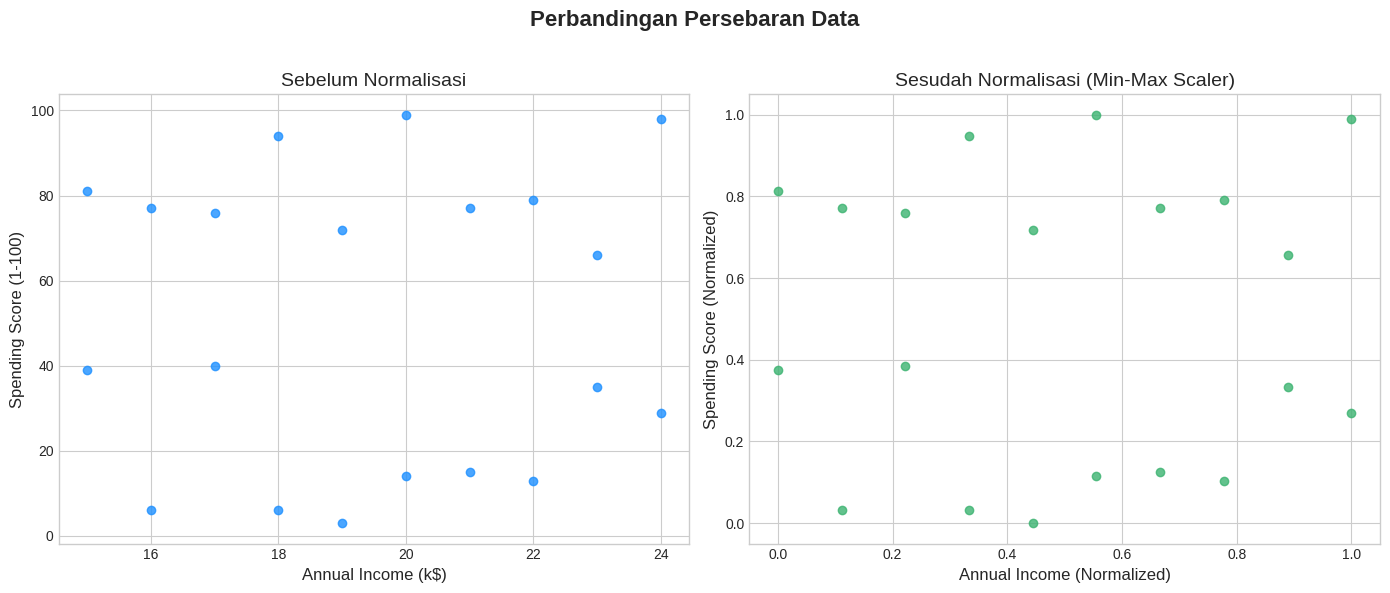

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Ganti 'path/to/your/data_customer.csv' dengan lokasi file Anda
file_path = 'data_customer.csv'
df = pd.read_csv(file_path)

# Pilih fitur AnnualIncome dan SpendingScore
features = df[['AnnualIncome', 'SpendingScore']]

# Inisialisasi scaler dan lakukan normalisasi
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)
df_normalized = pd.DataFrame(normalized_features, columns=['AnnualIncome', 'SpendingScore'])

print("Data berhasil dimuat dan dinormalisasi.")

# Membuat plot perbandingan
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Sebelum Normalisasi
ax1.scatter(df['AnnualIncome'], df['SpendingScore'], c='dodgerblue', alpha=0.8)
ax1.set_title('Sebelum Normalisasi', fontsize=14)
ax1.set_xlabel('Annual Income (k$)', fontsize=12)
ax1.set_ylabel('Spending Score (1-100)', fontsize=12)

# Plot Sesudah Normalisasi
ax2.scatter(df_normalized['AnnualIncome'], df_normalized['SpendingScore'], c='mediumseagreen', alpha=0.8)
ax2.set_title('Sesudah Normalisasi (Min-Max Scaler)', fontsize=14)
ax2.set_xlabel('Annual Income (Normalized)', fontsize=12)
ax2.set_ylabel('Spending Score (Normalized)', fontsize=12)

plt.suptitle('Perbandingan Persebaran Data', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.Clustering dengan K-Means

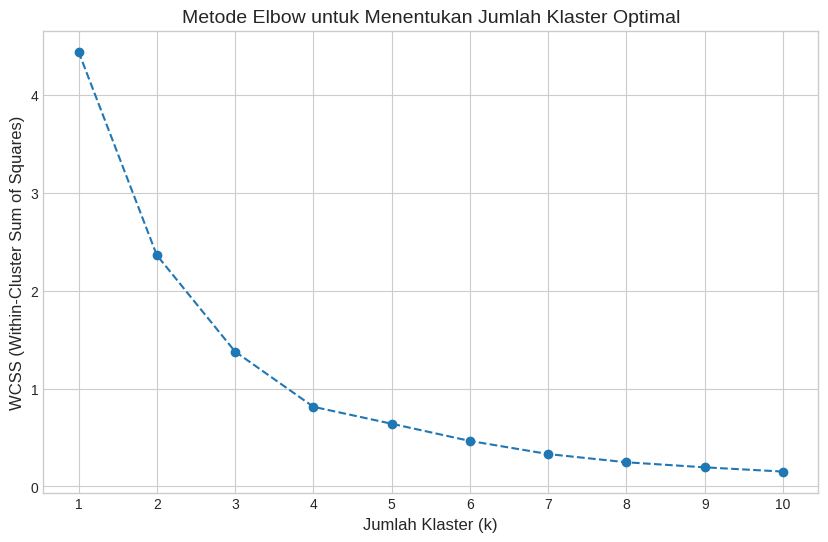

In [3]:
# Menyiapkan list untuk menyimpan nilai WCSS
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_normalized)
    wcss.append(kmeans.inertia_)

# Plot Metode Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal', fontsize=14)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

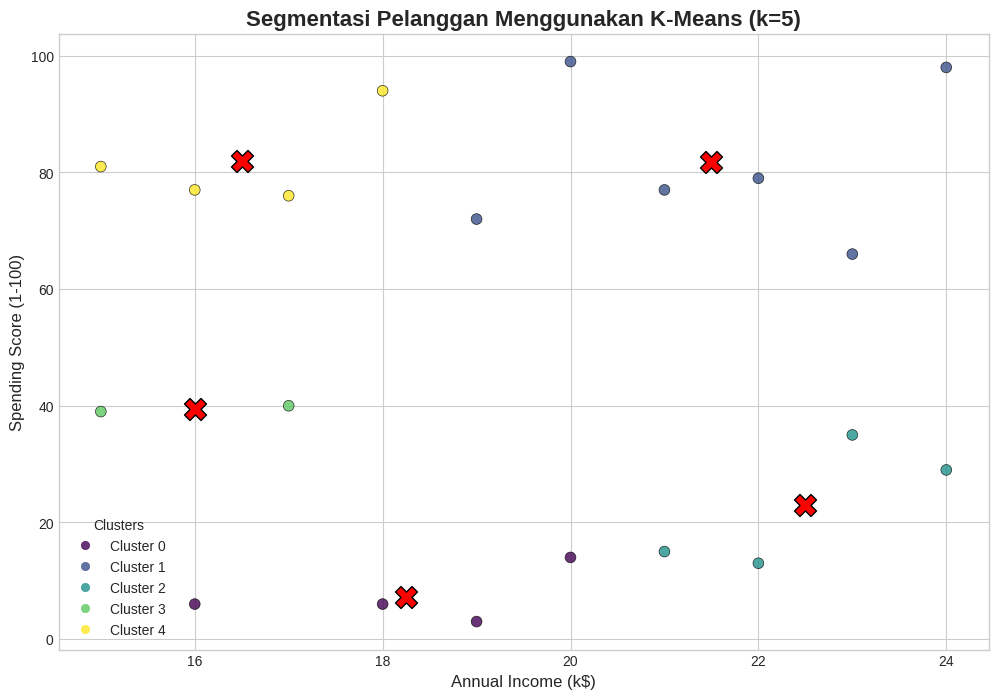

In [4]:
# Terapkan K-Means dengan k optimal = 5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_normalized)

# Tambahkan kolom 'Cluster' ke DataFrame asli
df['Cluster'] = cluster_labels

# Dapatkan titik pusat (centroids) dan kembalikan ke skala asli
centroids_normalized = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_normalized)

# Visualisasi hasil clustering
plt.figure(figsize=(12, 8))
# Scatter plot untuk setiap klaster
scatter = plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis',
                      alpha=0.8, s=60, edgecolors='black', linewidth=0.5)

# Plot centroids
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], s=250, c='red', marker='X',
            label='Centroids', edgecolors='black')

plt.title(f'Segmentasi Pelanggan Menggunakan K-Means (k={optimal_k})', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

# Membuat legenda yang rapi
legend_elements = scatter.legend_elements()
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
plt.legend(handles=legend_elements[0], labels=legend_labels, title="Clusters")
plt.show()

In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# --- Persiapan Data (Diperlukan agar kode bisa berjalan mandiri) ---
# Ganti dengan path file Anda jika perlu
df = pd.read_csv('data_customer.csv')
features = df[['AnnualIncome', 'SpendingScore']]
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)

# --- Langkah 4b ---
# Terapkan K-Means dengan k optimal = 5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(normalized_features)

# Tambahkan kolom 'Cluster' ke DataFrame asli
df['Cluster'] = cluster_labels

# Tampilkan 5 data pertama dengan kolom cluster baru
print("Data pelanggan setelah ditambahkan label cluster:")
print(df.head())

Data pelanggan setelah ditambahkan label cluster:
   CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0           1   19            15             39        3
1           2   21            15             81        4
2           3   20            16              6        0
3           4   23            16             77        4
4           5   31            17             40        3
